In [1]:
import os
import sys
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.colors import TwoSlopeNorm
from matplotlib.figure import Figure

sys.path.append(os.path.abspath(".."))

import src.charts.constants as ChartConstants
import src.charts.style as ChartStyle
from src.sources import PROCESSED_DIR
from src.transform.constants import QILT_SHORT_MEDIUM_OUTCOME_SPECS


In [2]:
def create_transition_problem_chart(transition_table: pd.DataFrame) -> Figure:
    ChartStyle.apply_chart_style()
    x_positions = np.arange(len(transition_table))
    period_labels = transition_table["period_label"].tolist()

    figure, axes = plt.subplots(
        nrows=len(QILT_SHORT_MEDIUM_OUTCOME_SPECS),
        ncols=1,
        figsize=(8.8, 7.9),
        sharex=True,
        gridspec_kw={"height_ratios": ChartConstants.TRANSITION_PANEL_HEIGHT_RATIOS},
    )

    for axis, (outcome_key, short_column, medium_column) in zip(
        axes, QILT_SHORT_MEDIUM_OUTCOME_SPECS
    ):
        panel_style = ChartConstants.TRANSITION_PANEL_STYLES[outcome_key]
        short_values = transition_table[short_column].to_numpy(dtype=float)
        medium_values = transition_table[medium_column].to_numpy(dtype=float)

        axis.plot(
            x_positions,
            short_values,
            color=ChartConstants.SHORT_TERM_COLOR,
            linewidth=panel_style["short_linewidth"],
            marker="o",
            markersize=panel_style["marker_size"],
            markeredgecolor="white",
            markeredgewidth=0.9,
            alpha=panel_style["alpha"],
            label=ChartConstants.TRANSITION_SHORT_TERM_LABEL,
        )
        axis.plot(
            x_positions,
            medium_values,
            color=ChartConstants.MEDIUM_TERM_COLOR,
            linewidth=panel_style["medium_linewidth"],
            marker="o",
            markersize=max(panel_style["marker_size"] - 0.5, 4.0),
            markerfacecolor="white",
            markeredgecolor=ChartConstants.MEDIUM_TERM_COLOR,
            markeredgewidth=1.0,
            alpha=max(panel_style["alpha"] - 0.08, 0.45),
            label=ChartConstants.TRANSITION_MEDIUM_TERM_LABEL,
        )
        _style_transition_axis(
            axis,
            title=ChartConstants.QILT_OUTCOME_TITLES[outcome_key],
            title_alpha=panel_style["title_alpha"],
        )
        axis.set_ylim(*ChartConstants.TRANSITION_Y_LIMITS)
        axis.set_yticks(ChartConstants.TRANSITION_Y_TICKS)

    axes[-1].set_xticks(x_positions, period_labels)
    axes[-1].set_xlabel("Graduation year")

    ChartStyle.add_figure_legend(
        figure,
        axes[0],
        anchor=ChartConstants.TRANSITION_LEGEND_ANCHOR,
    )

    figure.suptitle(
        ChartConstants.TRANSITION_CHART_TITLE,
        fontsize=ChartConstants.SUBGROUP_CHART_TITLE_FONT_SIZE,
        color=ChartConstants.TEXT_COLOR,
        x=0.08,
        y=ChartConstants.TRANSITION_SUPTITLE_Y,
        ha="left",
    )

    figure.tight_layout(rect=ChartConstants.TRANSITION_TIGHT_LAYOUT_RECT)
    return ChartStyle.draw_figure(figure)


def _style_transition_axis(axis: Axes, *, title: str, title_alpha: float) -> None:
    axis.set_title(
        title,
        loc="left",
        fontsize=ChartConstants.AXIS_TITLE_FONT_SIZE,
        color=ChartConstants.TEXT_COLOR,
        alpha=title_alpha,
    )
    axis.set_ylabel("Percentage")
    axis.grid(
        axis="y",
        color=ChartConstants.GRID_COLOR,
        linewidth=ChartConstants.AXIS_GRID_LINEWIDTH,
    )
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.tick_params(colors=ChartConstants.TEXT_COLOR)


def create_unequal_distribution_chart(levels_table: pd.DataFrame) -> Figure:
    ChartStyle.apply_chart_style()
    ordered_table = levels_table.sort_values(
        ["row_group_order", "row_group"],
        kind="mergesort",
    ).reset_index(drop=True)
    row_positions = np.arange(len(ordered_table))

    figure, axes = plt.subplots(
        nrows=1,
        ncols=len(QILT_SHORT_MEDIUM_OUTCOME_SPECS),
        figsize=(12.4, 5.8),
        sharey=True,
        gridspec_kw={"width_ratios": ChartConstants.UNEQUAL_PANEL_WIDTH_RATIOS},
    )

    for axis, (outcome_key, _, _) in zip(axes, QILT_SHORT_MEDIUM_OUTCOME_SPECS):
        panel_style = ChartConstants.UNEQUAL_PANEL_STYLES[outcome_key]
        low_values = pd.to_numeric(
            ordered_table[f"{outcome_key}_low_value"],
            errors="coerce",
        ).to_numpy(dtype=float)
        high_values = pd.to_numeric(
            ordered_table[f"{outcome_key}_high_value"],
            errors="coerce",
        ).to_numpy(dtype=float)
        gap_values = pd.to_numeric(
            ordered_table[f"{outcome_key}_gap"],
            errors="coerce",
        ).to_numpy(dtype=float)
        available_mask = np.isfinite(low_values) & np.isfinite(high_values)

        axis.hlines(
            row_positions[available_mask],
            low_values[available_mask],
            high_values[available_mask],
            color=ChartConstants.CONNECTOR_COLOR,
            linewidth=panel_style["line_width"],
            alpha=panel_style["alpha"],
            zorder=ChartConstants.DUMBBELL_CONNECTOR_ZORDER,
        )
        axis.scatter(
            low_values[available_mask],
            row_positions[available_mask],
            color=ChartConstants.SHORT_TERM_COLOR,
            s=panel_style["marker_size"],
            label="Lower subgroup in pair",
            alpha=panel_style["alpha"],
            zorder=ChartConstants.DUMBBELL_LEFT_POINT_ZORDER,
        )
        axis.scatter(
            high_values[available_mask],
            row_positions[available_mask],
            facecolors="white",
            edgecolors=ChartConstants.SHORT_TERM_COLOR,
            linewidths=1.4,
            s=panel_style["marker_size"],
            label="Higher subgroup in pair",
            alpha=panel_style["alpha"],
            zorder=ChartConstants.DUMBBELL_RIGHT_POINT_ZORDER,
        )

        for row_index in np.flatnonzero(available_mask):
            gap_value = gap_values[row_index]
            axis.text(
                min(
                    max(low_values[row_index], high_values[row_index])
                    + ChartConstants.UNEQUAL_GAP_LABEL_OFFSET,
                    ChartConstants.SUBGROUP_LEVELS_X_AXIS.maximum - 0.4,
                ),
                row_positions[row_index],
                f"{gap_value:.1f} pp",
                fontsize=8,
                color=ChartConstants.TEXT_COLOR,
                ha="left",
                va="center",
                alpha=panel_style["alpha"],
            )

        for row_index in np.flatnonzero(~available_mask):
            availability_note = (
                ordered_table.iloc[row_index][f"{outcome_key}_availability_note"]
                or ordered_table.iloc[row_index]["availability_note"]
                or "Unavailable"
            )
            axis.text(
                ChartConstants.SUBGROUP_LEVELS_X_AXIS.minimum + 1.0,
                row_positions[row_index],
                str(availability_note),
                fontsize=8,
                color=ChartConstants.TEXT_COLOR,
                ha="left",
                va="center",
                alpha=0.8,
            )

        ChartStyle.style_outcome_axis(
            axis,
            title=ChartConstants.QILT_OUTCOME_TITLES[outcome_key],
            x_label="2024 short-term rate (percentage)",
        )
        axis.title.set_alpha(panel_style["title_alpha"])
        axis.set_xlim(*ChartConstants.SUBGROUP_LEVELS_X_AXIS.limits)
        axis.set_xticks(ChartConstants.SUBGROUP_LEVELS_X_AXIS.ticks)

    ChartStyle.draw_group_pair_y_labels(
        axes[0],
        row_positions,
        ordered_table["row_group"],
        ordered_table["pair_label"],
    )

    for axis in axes[1:]:
        axis.tick_params(axis="y", left=False, labelleft=False)

    ChartStyle.add_figure_legend(
        figure,
        axes[0],
        anchor=(0.98, 0.985),
    )

    figure.suptitle(
        ChartConstants.UNEQUAL_DISTRIBUTION_TITLE,
        fontsize=ChartConstants.SUBGROUP_CHART_TITLE_FONT_SIZE,
        color=ChartConstants.TEXT_COLOR,
        x=0.11,
        ha="left",
    )
    figure.tight_layout(rect=(0, 0, 1, 0.94))
    return ChartStyle.draw_figure(figure)


def create_catch_up_gap_width_chart(gap_width_table: pd.DataFrame) -> Figure:
    ChartStyle.apply_chart_style()
    ordered_table = gap_width_table.sort_values(
        ["row_group_order", "row_group"],
        kind="mergesort",
    ).reset_index(drop=True)
    reference_rows = (
        ordered_table.loc[ordered_table["outcome_key"] == "full_time_employment"]
        .sort_values(["row_group_order", "row_group"], kind="mergesort")
        .reset_index(drop=True)
    )
    row_positions = np.arange(len(reference_rows))

    figure, axes = plt.subplots(
        nrows=1,
        ncols=len(QILT_SHORT_MEDIUM_OUTCOME_SPECS),
        figsize=(11.9, 5.6),
        sharey=True,
        gridspec_kw={"width_ratios": ChartConstants.GAP_WIDTH_PANEL_WIDTH_RATIOS},
    )

    for axis, (outcome_key, _, _) in zip(axes, QILT_SHORT_MEDIUM_OUTCOME_SPECS):
        panel_style = ChartConstants.GAP_WIDTH_PANEL_STYLES[outcome_key]
        outcome_table = (
            ordered_table.loc[ordered_table["outcome_key"] == outcome_key]
            .sort_values(["row_group_order", "row_group"], kind="mergesort")
            .reset_index(drop=True)
        )
        short_gaps = pd.to_numeric(
            outcome_table["short_term_gap"],
            errors="coerce",
        ).to_numpy(dtype=float)
        medium_gaps = pd.to_numeric(
            outcome_table["medium_term_gap"],
            errors="coerce",
        ).to_numpy(dtype=float)
        available_mask = np.isfinite(short_gaps) & np.isfinite(medium_gaps)

        axis.hlines(
            row_positions[available_mask],
            short_gaps[available_mask],
            medium_gaps[available_mask],
            color=ChartConstants.CONNECTOR_COLOR,
            linewidth=panel_style["line_width"],
            alpha=panel_style["alpha"],
            zorder=ChartConstants.DUMBBELL_CONNECTOR_ZORDER,
        )
        axis.scatter(
            short_gaps[available_mask],
            row_positions[available_mask],
            color=ChartConstants.SHORT_TERM_COLOR,
            s=panel_style["marker_size"],
            label=ChartConstants.CATCH_UP_SHORT_TERM_LABEL,
            alpha=panel_style["alpha"],
            zorder=ChartConstants.DUMBBELL_LEFT_POINT_ZORDER,
        )
        axis.scatter(
            medium_gaps[available_mask],
            row_positions[available_mask],
            color=ChartConstants.MEDIUM_TERM_COLOR,
            edgecolors="white",
            linewidths=0.9,
            s=panel_style["marker_size"],
            label=ChartConstants.CATCH_UP_MEDIUM_TERM_LABEL,
            alpha=panel_style["alpha"],
            zorder=ChartConstants.DUMBBELL_RIGHT_POINT_ZORDER,
        )
        ChartStyle.style_outcome_axis(
            axis,
            title=ChartConstants.QILT_OUTCOME_TITLES[outcome_key],
            x_label="Gap width (percentage points)",
        )
        axis.title.set_alpha(panel_style["title_alpha"])
        axis.set_xlim(*ChartConstants.SUBGROUP_GAP_WIDTH_X_AXIS.limits)
        axis.set_xticks(ChartConstants.SUBGROUP_GAP_WIDTH_X_AXIS.ticks)

    ChartStyle.draw_group_pair_y_labels(
        axes[0],
        row_positions,
        reference_rows["row_group"],
        reference_rows["pair_label"],
    )
    axes[0].axvline(
        0,
        color=ChartConstants.GRID_COLOR,
        linewidth=1.0,
        zorder=0,
    )

    for axis in axes[1:]:
        axis.tick_params(axis="y", left=False, labelleft=False)

    ChartStyle.add_figure_legend(
        figure,
        axes[0],
        anchor=(0.98, 0.985),
    )

    figure.suptitle(
        ChartConstants.CATCH_UP_GAP_WIDTH_TITLE,
        fontsize=ChartConstants.SUBGROUP_CHART_TITLE_FONT_SIZE,
        color=ChartConstants.TEXT_COLOR,
        x=0.08,
        ha="left",
    )
    figure.tight_layout(rect=(0, 0, 1, 0.94))
    return ChartStyle.draw_figure(figure)


def create_catch_up_levels_chart(
    levels_table: pd.DataFrame,
    *,
    row_group_order: Optional[list[str]] = None,
) -> Figure:
    ChartStyle.apply_chart_style()
    ordered_table = _order_levels_table(
        levels_table,
        row_group_order=row_group_order,
    )
    row_positions = np.arange(len(ordered_table))
    chart_labels = ChartStyle.build_group_chart_labels(
        ordered_table["row_group"],
        ordered_table["row_label"],
    )
    group_boundaries = ChartStyle.build_group_boundaries(ordered_table)
    group_header_mask = ChartStyle.build_group_header_mask(ordered_table["row_group"])

    figure, axes = plt.subplots(
        nrows=len(QILT_SHORT_MEDIUM_OUTCOME_SPECS),
        ncols=1,
        figsize=(9.0, 10.5),
        sharey=True,
    )

    for axis, (outcome_key, short_column, medium_column) in zip(
        axes, QILT_SHORT_MEDIUM_OUTCOME_SPECS
    ):
        short_values = ordered_table[short_column].to_numpy(dtype=float)
        medium_values = ordered_table[medium_column].to_numpy(dtype=float)

        ChartStyle.plot_dumbbell_series(
            axis,
            row_positions,
            short_values,
            medium_values,
            left_label="Short-term",
            right_label="Medium-term",
            marker_size=30,
        )
        ChartStyle.draw_group_boundaries(axis, group_boundaries)
        ChartStyle.style_outcome_axis(
            axis,
            title=ChartConstants.QILT_OUTCOME_TITLES[outcome_key],
            x_label="Percentage",
        )
        axis.set_xlim(*ChartConstants.SUBGROUP_LEVELS_X_AXIS.limits)
        axis.set_xticks(ChartConstants.SUBGROUP_LEVELS_X_AXIS.ticks)
        axis.set_yticks(row_positions, chart_labels)
        axis.tick_params(axis="y", left=False, labelleft=True, pad=4)
        ChartStyle.style_group_header_ticks(axis, group_header_mask)

    ChartStyle.add_figure_legend(
        figure,
        axes[0],
        anchor=(0.98, 0.965),
    )

    figure.suptitle(
        ChartConstants.CATCH_UP_LEVELS_TITLE,
        fontsize=ChartConstants.SUBGROUP_CHART_TITLE_FONT_SIZE,
        color=ChartConstants.TEXT_COLOR,
        x=0.12,
        ha="left",
    )
    figure.tight_layout(rect=(0, 0, 1, 0.93))
    return ChartStyle.draw_figure(figure)


def create_catch_up_change_heatmap(
    levels_table: pd.DataFrame,
    *,
    row_group_order: Optional[list[str]] = None,
) -> Figure:
    ChartStyle.apply_chart_style()
    ordered_table = _order_levels_table(
        levels_table,
        row_group_order=row_group_order,
    )
    outcome_keys = [outcome_key for outcome_key, _, _ in QILT_SHORT_MEDIUM_OUTCOME_SPECS]
    change_columns = [f"{outcome_key}_change" for outcome_key in outcome_keys]
    change_matrix = ordered_table[change_columns].to_numpy(dtype=float)
    max_change = max(
        float(np.abs(change_matrix).max()),
        ChartConstants.SUBGROUP_CHANGE_HEATMAP_MIN_ABS_CHANGE,
    )
    group_boundaries = ChartStyle.build_group_boundaries(ordered_table)
    group_header_mask = ChartStyle.build_group_header_mask(ordered_table["row_group"])

    figure, axis = plt.subplots(figsize=(6.4, 8.0))

    heatmap = axis.imshow(
        change_matrix,
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-max_change, vcenter=0.0, vmax=max_change),
        aspect="auto",
    )

    axis.set_xticks(np.arange(len(outcome_keys)))
    axis.set_xticklabels(
        [ChartConstants.QILT_OUTCOME_SHORT_TITLES[outcome_key] for outcome_key in outcome_keys]
    )
    axis.set_yticks(np.arange(len(ordered_table)))
    axis.set_yticklabels(
        ChartStyle.build_group_chart_labels(
            ordered_table["row_group"],
            ordered_table["row_label"],
        )
    )
    axis.set_title(
        ChartConstants.CATCH_UP_CHANGE_HEATMAP_TITLE,
        loc="left",
        fontsize=ChartConstants.SUBGROUP_CHART_TITLE_FONT_SIZE,
        color=ChartConstants.TEXT_COLOR,
    )
    axis.tick_params(colors=ChartConstants.TEXT_COLOR)

    for boundary in group_boundaries:
        axis.axhline(
            boundary,
            color="white",
            linewidth=2.0,
        )

    for row_index in range(change_matrix.shape[0]):
        for column_index in range(change_matrix.shape[1]):
            value = change_matrix[row_index, column_index]
            text_color = (
                "white"
                if abs(value) >= max_change * 0.55
                else ChartConstants.TEXT_COLOR
            )
            axis.text(
                column_index,
                row_index,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=7,
                color=text_color,
            )

    ChartStyle.style_group_header_ticks(axis, group_header_mask)

    colorbar = figure.colorbar(
        heatmap,
        ax=axis,
        shrink=0.84,
        pad=0.03,
    )
    colorbar.set_label("Change (percentage points)", color=ChartConstants.TEXT_COLOR)
    colorbar.ax.yaxis.set_tick_params(color=ChartConstants.TEXT_COLOR)
    plt.setp(colorbar.ax.get_yticklabels(), color=ChartConstants.TEXT_COLOR)

    figure.tight_layout()
    return ChartStyle.draw_figure(figure)


def _order_levels_table(
    levels_table: pd.DataFrame,
    *,
    row_group_order: Optional[list[str]],
) -> pd.DataFrame:
    ordered_table = levels_table.copy()
    ordered_row_groups = row_group_order or ordered_table["row_group"].drop_duplicates().tolist()
    ordered_table["row_group_sort"] = pd.Categorical(
        ordered_table["row_group"],
        categories=ordered_row_groups,
        ordered=True,
    )
    ordered_table = ordered_table.sort_values(
        ["row_group_sort", "short_term_full_time_employment", "row_label"],
        kind="mergesort",
    ).reset_index(drop=True)
    return ordered_table.drop(columns="row_group_sort")


In [3]:
transition_problem_table = pd.read_csv(PROCESSED_DIR / "archived" / "transition_problem.csv")
unequal_distribution_table = pd.read_csv(PROCESSED_DIR / "archived" / "unequal_distribution.csv")
catch_up_levels_table = pd.read_csv(PROCESSED_DIR / "archived" / "catch_up_levels.csv")
catch_up_gap_width_table = pd.read_csv(PROCESSED_DIR / "archived" / "catch_up_gap_width.csv")

row_group_order = catch_up_gap_width_table.loc[
    catch_up_gap_width_table["outcome_key"] == "full_time_employment",
    "row_group",
].tolist()


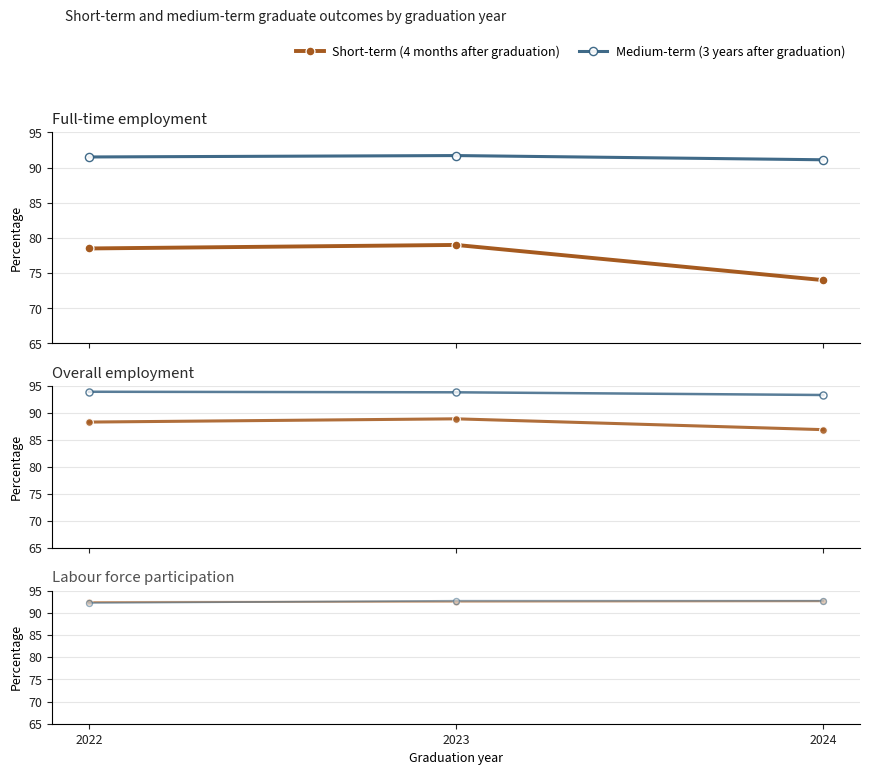

In [4]:
transition_problem_figure = create_transition_problem_chart(transition_problem_table)
transition_problem_figure


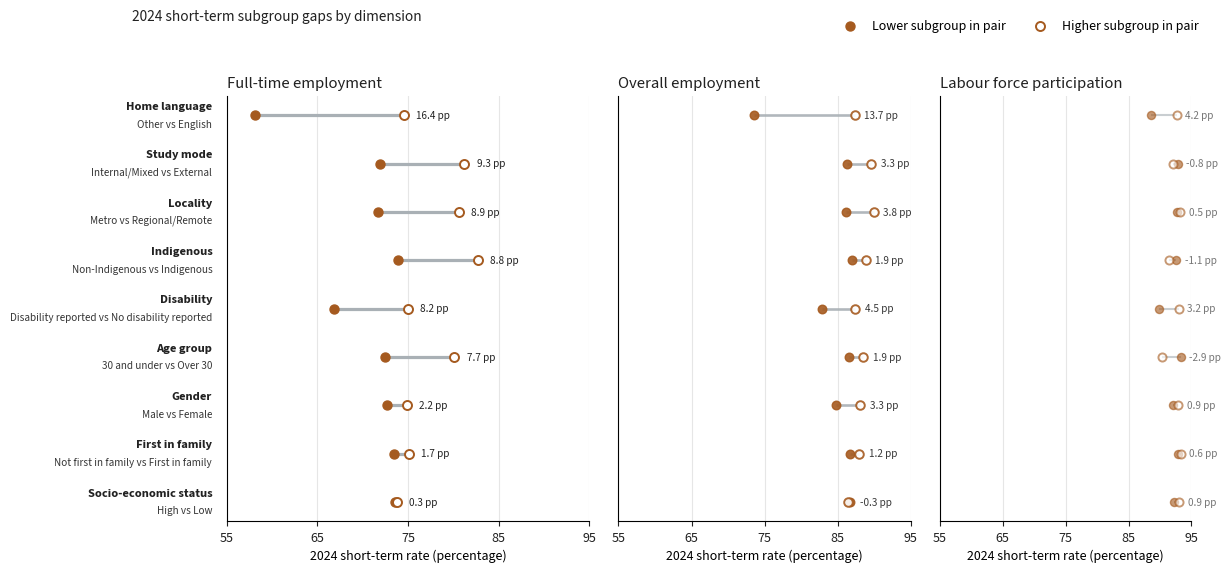

In [5]:
unequal_distribution_figure = create_unequal_distribution_chart(
    unequal_distribution_table,
)
unequal_distribution_figure


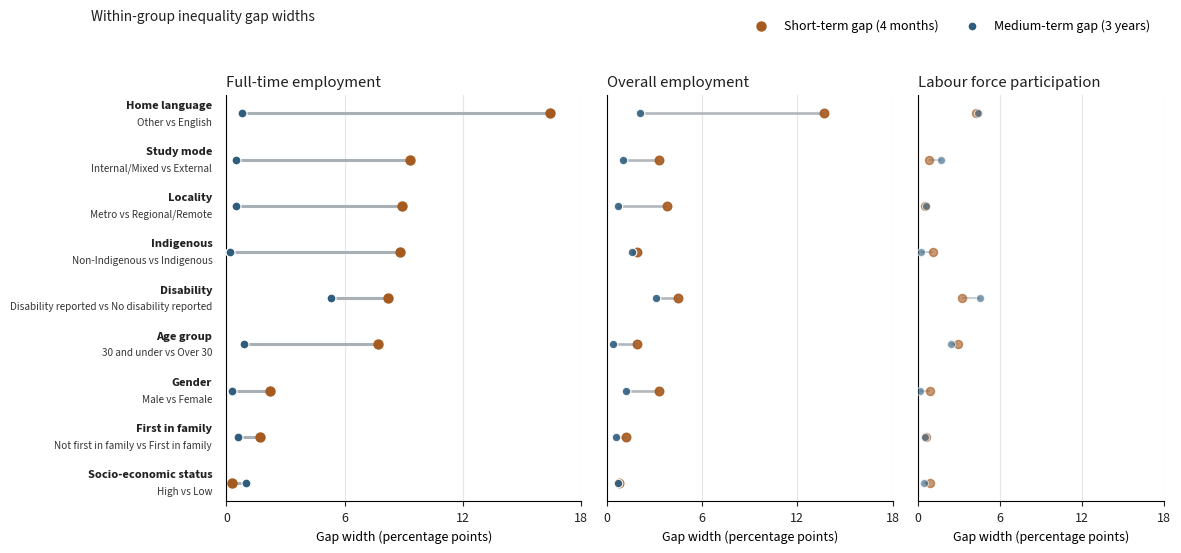

In [6]:
gap_width_figure = create_catch_up_gap_width_chart(catch_up_gap_width_table)
gap_width_figure


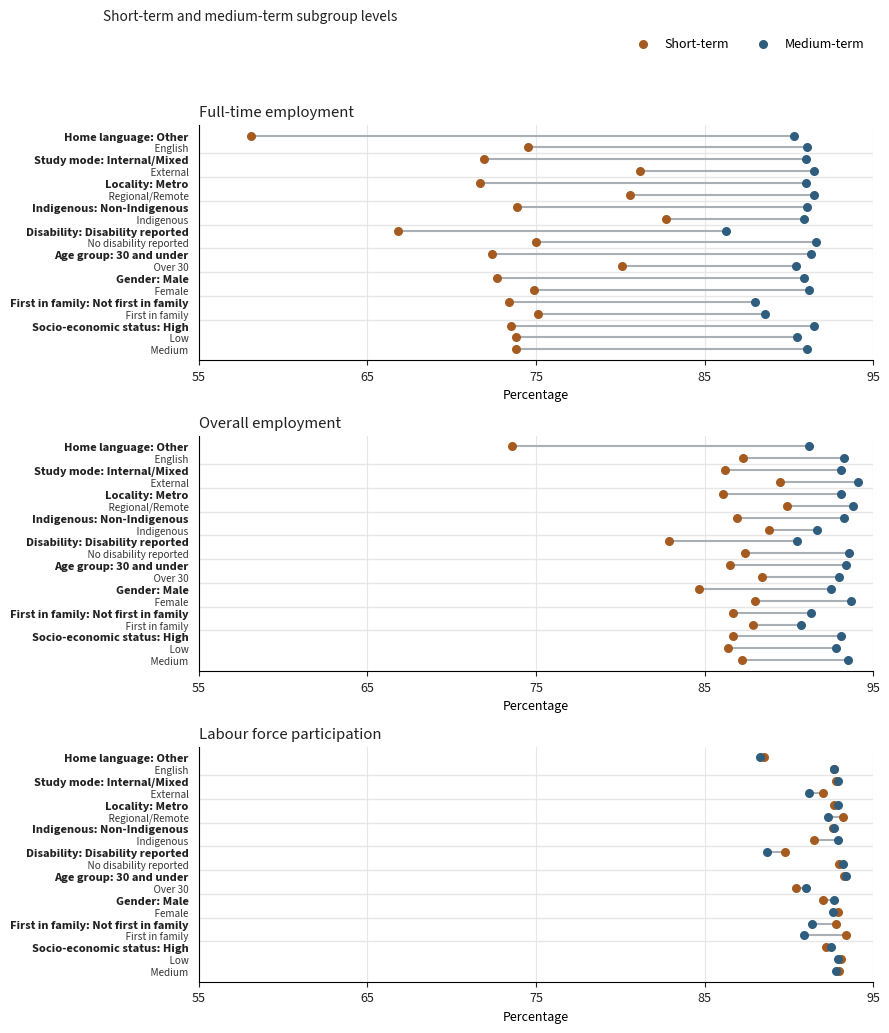

In [7]:
levels_figure = create_catch_up_levels_chart(
    catch_up_levels_table,
    row_group_order=row_group_order,
)
levels_figure


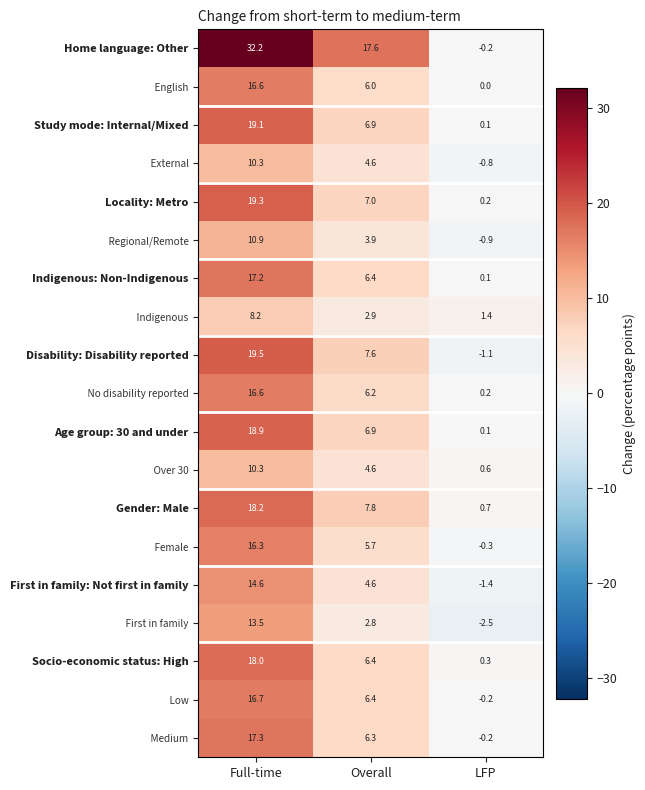

In [8]:
change_heatmap_figure = create_catch_up_change_heatmap(
    catch_up_levels_table,
    row_group_order=row_group_order,
)
change_heatmap_figure
